#Question & Answer


Creating a Question-Answer Transformer model or QA Transformer can be beneficial for several reasons, particularly in the field of Natural Language Processing (NLP). Here are some compelling reasons why you might want to develop a QA Transformer:

1. Question-Answering Systems: QA Transformers are designed to provide accurate and contextually relevant answers to questions posed in natural language. These systems have a wide range of practical applications, including chatbots, virtual assistants, customer support, and information retrieval.

2. Information Retrieval: QA Transformers can be used to search through large corpora of text and extract precise answers to user queries. This can improve the efficiency and effectiveness of information retrieval systems.

3. Document Summarization: QA Transformers can be used to summarize long documents by answering questions about the document's content. This makes it easier for users to quickly understand the key points and relevant information in a text.

4. Education and E-Learning: QA Transformers can be integrated into educational platforms to provide instant answers and explanations to students' questions. They can also help with the automatic generation of quiz questions and answers.

5. Content Generation: QA Transformers can assist in content generation by automatically answering questions based on available knowledge. This can be useful for generating FAQs, product descriptions, and informative articles.

6. Customer Support: Many companies use QA systems to automate responses to frequently asked questions, freeing up human agents to handle more complex queries and providing customers with quick solutions.

7. Medical Diagnosis: QA Transformers can assist medical professionals by answering questions related to patient records, medical literature, and diagnostic information, potentially leading to faster and more accurate diagnoses.

8. Legal and Compliance: In the legal field, QA Transformers can be used to search and extract information from legal documents, assisting lawyers in their research and case preparation.

9. Language Translation: QA Transformers can be used to answer questions about language translation, helping users understand the meaning of words, phrases, or sentences in different languages.

10. Scientific Research: QA Transformers can support researchers by answering questions related to scientific literature, allowing them to quickly access relevant information for their studies.

11. Decision Support: QA Transformers can aid in decision-making processes by providing answers to questions related to data analysis, market research, and business intelligence.

12. Accessibility: QA Transformers can improve accessibility for individuals with disabilities by providing spoken or written answers to their questions, helping them access information more easily.

Overall, QA Transformers have the potential to enhance information retrieval, automation, and user interaction in various domains, making them a valuable tool in the development of intelligent systems and applications. The ability to provide accurate and context-aware answers to questions in natural language is a key advantage of these models.



Exercise:

Now, as a data scientist expert in NLP, you are asked to create a model to be able to answer question in Spanish. Your stakeholders will pass you an article and one question and your model should answer it.

In [ ]:
!pip install requests beautifulsoup4

Esta primera parte realiza una técnica para obtener el texto desde una página WEB. La URL que se esta utilizando es la siguiente: https://time.com/collection/time100-ai/6309026/geoffrey-hinton/. A través de la librería requests, es posible realizar peticiones HTTP posteriormente lo que se realiza a través de la sentencia BeatifulSoup es lograr recorrer todo el contenido de texto que esta presente en la página y lograr extaer este texto de forma estructurada. A través de la senttencia soup.find se busca el contenido del artículo para así parsearlo esta busqueda la realiza según la estructura del código HTML que se puede confirmar inspeccionando la misma página WEB y localizando el tag de class="article-content" como se peude ver en la imagen. Posteriormente lo que se realiza es la extracción del texto correspondiente. 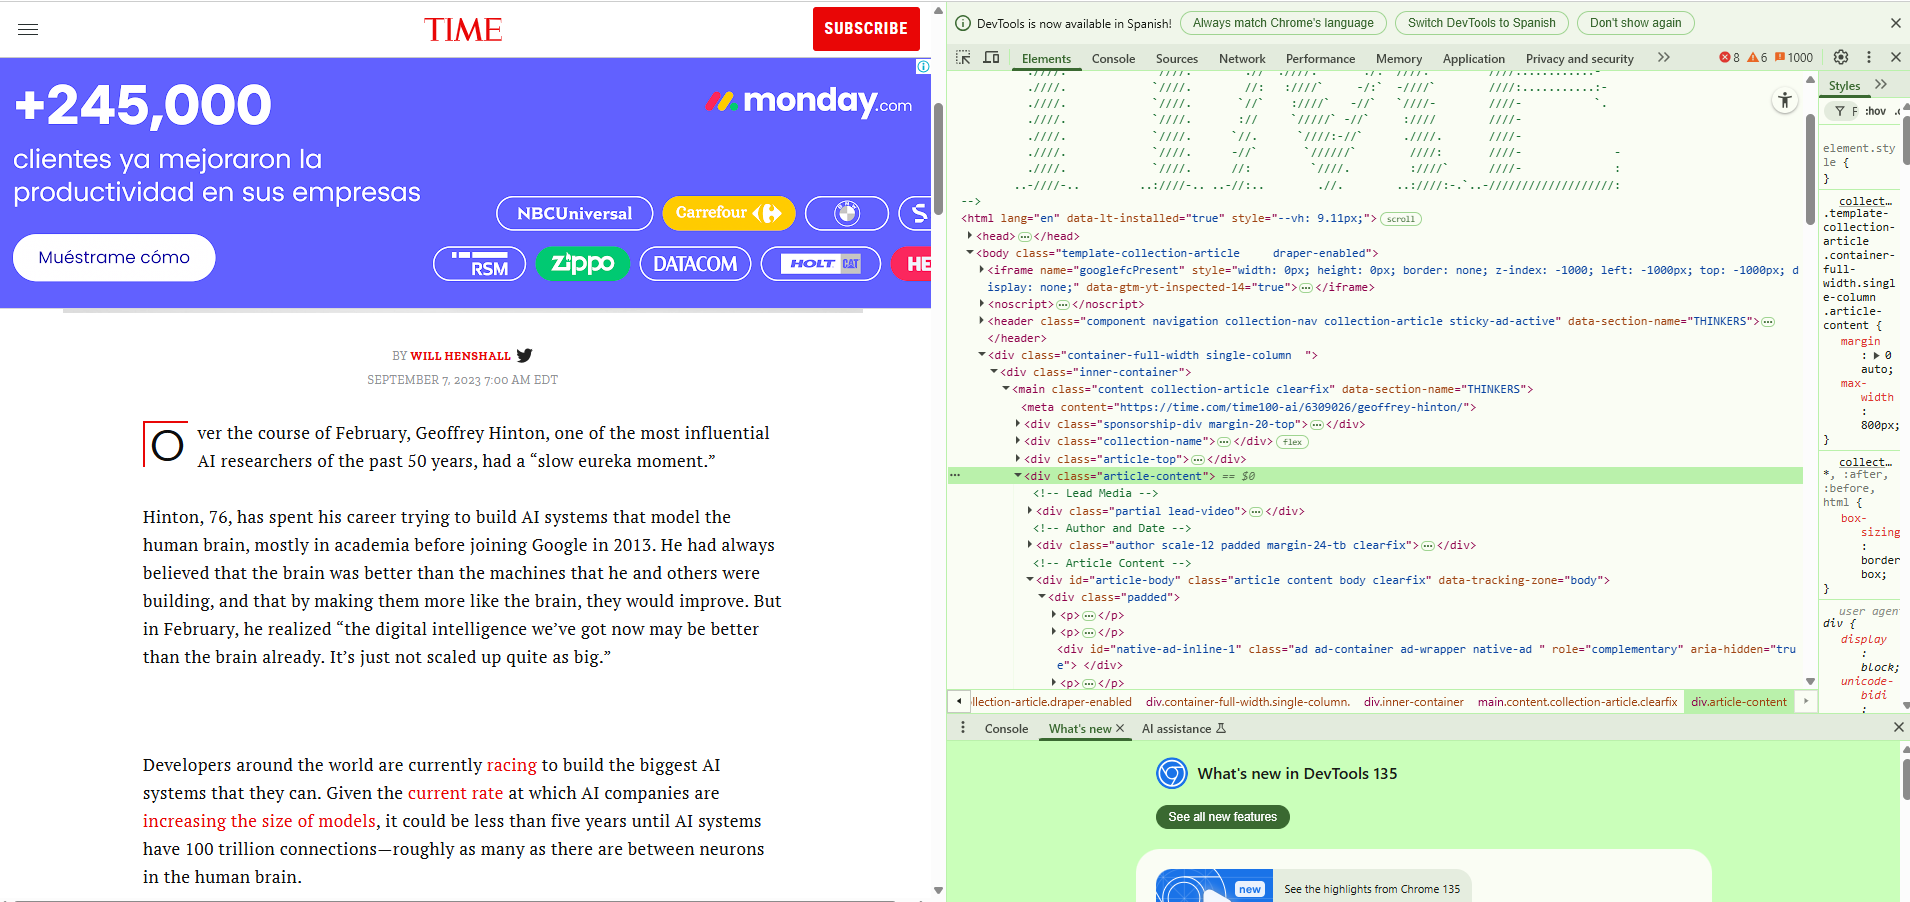

In [ ]:
import requests
from bs4 import BeautifulSoup

# URL del artículo
url = "https://time.com/collection/time100-ai/6309026/geoffrey-hinton/"

# Realizar una solicitud HTTP para obtener el contenido de la página
response = requests.get(url)

# Verificar si la solicitud fue exitosa
if response.status_code == 200:
    # Analizar el contenido HTML de la página con BeautifulSoup
    soup = BeautifulSoup(response.text, "html.parser")

    # Encontrar el contenido del artículo (puedes inspeccionar el HTML de la página para encontrar la estructura adecuada)
    article_content = soup.find("div", {"class": "article-content"})

    # Extraer el texto del artículo
    article_text = ""
    for paragraph in article_content.find_all("p"):
        article_text += paragraph.get_text() + "\n"

    # Imprimir el texto del artículo
    print(article_text)
else:
    print("Error al obtener la página:", response.status_code)

Over the course of February, Geoffrey Hinton, one of the most influential AI researchers of the past 50 years, had a “slow eureka moment.”
Hinton, 76, has spent his career trying to build AI systems that model the human brain, mostly in academia before joining Google in 2013. He had always believed that the brain was better than the machines that he and others were building, and that by making them more like the brain, they would improve. But in February, he realized “the digital intelligence we’ve got now may be better than the brain already. It’s just not scaled up quite as big.” 
Developers around the world are currently racing to build the biggest AI systems that they can. Given the current rate at which AI companies are increasing the size of models, it could be less than five years until AI systems have 100 trillion connections—roughly as many as there are between neurons in the human brain.
Alarmed, Hinton left his post as VP and engineering fellow in May and gave a flurry of in

In [ ]:
question = "How is Geoffrey Hinton?"

Este fragmento de código se basa en la utilización de técnicas como TF-IDF y similitud de coseno para implementar un sistema de Preguntas-Respuesta, lo anterior sin tener que recurrir a modelos preentrenados de NLP. Los pasos principales de este fragmento son:
1. Se importan librerías necesarias: Se importan las librerias nltk para tokenización y eliminación de stopwords. También se importa la liberria sklearn para el cálculo de vectores TF-IDF y similutd de coseno. Finalmente se importa numpy para operaciones numéricas y vectoriales.
2. A través de la sentencia preprocess_text(), se realiza el preprocesamiento dle texto donde se realiza un tratamiento del texto para dejarlo limpio y normalizado realizando principalmente las siguientes acciones: Convertir todo el texto en minusculas, eliminar los stopwords correspondientes, quitar puntuación y símbolos, y finalmente deja listo el texto para que sea sea usado por TF-IDF.
3. Una vez preparado el texto se define la función de Pregunta-Respuesta teniendo que cuenta que se esta definiendo la variable question como: "How is Geoffrey Hinton", esta función se implementa sin modelos preentrenados usando TF-IDF y Similitud de Coseno, de lo cual se tienen los siguientes componentes:
  1. Preprocesamiento de la pregunta y el contexto.
  2. División del contexto en oraciones con la funcion sent_tokenize
  3. Uso de la vectorización con TF-IDF, esta función lo que realiza principalmente es convertir la pregunta y cada oración en vectores numéricos.
  4. Uso del conseno de similaridad para calcular la similitud entre pregunta y cada oración.
  5. Una vez calculada la similitud entre pregunta y cada oración se devuelve la oración más similar catalogada como respuesta.

In [ ]:
import nltk
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

def preprocess_text(text):
    """Processes the text: tokenizes, removes stopwords, and converts to lowercase."""
    tokens = word_tokenize(text.lower())
    stop_words = set(stopwords.words('english')) # Changed to 'english'
    filtered_tokens = [w for w in tokens if not w in stop_words and w.isalnum()]
    return " ".join(filtered_tokens)

def answer_question_without_pretrained(question: str, context: str) -> str:
    """
    Attempts to answer a question given a context text without using pretrained models.
    Uses TF-IDF and cosine similarity to find the most relevant sentence.
    """
    processed_question = preprocess_text(question)
    processed_context = preprocess_text(context)
    context_sentences = nltk.sent_tokenize(context)
    processed_sentences = [preprocess_text(sentence) for sentence in context_sentences]

    vectorizer = TfidfVectorizer()
    vectorizer.fit([processed_question] + processed_sentences)

    question_vector = vectorizer.transform([processed_question])
    context_vectors = vectorizer.transform(processed_sentences)

    similarities = cosine_similarity(question_vector, context_vectors)

    if similarities.any():
        best_sentence_index = np.argmax(similarities)
        return context_sentences[best_sentence_index]
    else:
        return "Could not find a relevant answer based on similarity."

if __name__ == "__main__":
    text_example = article_text

    question_example_1 = question
    answer_1 = answer_question_without_pretrained(question_example_1, text_example)
    print(f"Question: {question_example_1}\nAnswer: {answer_1}\n")


Question: How is Geoffrey Hinton?
Answer: Over the course of February, Geoffrey Hinton, one of the most influential AI researchers of the past 50 years, had a “slow eureka moment.”
Hinton, 76, has spent his career trying to build AI systems that model the human brain, mostly in academia before joining Google in 2013.



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Con el modelo del fragemento anterior se plantea otro ejemplo de pregunta 'Which company did Hinton work for until 2023?'

In [ ]:
question_example_2 = "Which company did Hinton work for until 2023?"
answer_2 = answer_question_without_pretrained(question_example_2, text_example)
print(f"Question: {question_example_2}\nAnswer: {answer_2}\n")

Question: Which company did Hinton work for until 2023?
Answer: They set up a shell company called DNN-research to auction their expertise, and four tech firms—Google, Microsoft, Baidu, and DeepMind—bid tens of millions for the company.



De igual manera se prueba una tercera pregutna "What is his favorite color?"

In [ ]:
question_example_3 = "What is his favorite color?"
answer_3 = answer_question_without_pretrained(question_example_3, text_example)
print(f"Question: {question_example_3}\nAnswer: {answer_3}\n")

Question: What is his favorite color?
Answer: Could not find a relevant answer based on similarity.



In [ ]:
user_question = input("Enter your question: ")
user_text = input("Enter the context text: ")
user_answer = answer_question_without_pretrained(user_question, user_text)
print(f"\nUser Question: {user_question}\nProvided Text:\n{user_text}\nAnswer: {user_answer}")

Modelo pre-entrenado

Una vez probada la aplicación técnicas de TF-IDF y Similitud del Coseno se procede a realizar el ejercicio con un modelo pre-entrenado. El modelo de Pregunta-Respuesta (QA) usando Hugging Face, este modelo utiliza DeepLearning para la aplicación de Pregunta - Respuesta.
Este fragmento de código tiene las siguientes sentencias principales:
1. Se importa la interfaz pipeline de la liberia transformers.
2. Se define la función principal de Pregunta y Respuesta que tiene los siguientes componentes.
3. Inicialización del modelo de QA: Se crea el pipeline de QA usando el modelo preentrenado distilbert-base-cased-distilled-squad que es una versión de BERT entrenada con el dataset SQuAD, si bien es más rápida y menos costosa computacionalmente de bert-large, sigue siendo muy precisa.
4. Se ejecuta el modelo que devuelve la respuesta generada, la confianza del modelo y las posiciones del fragmento del texto original donde encontró la respuesta.
5. Se valida la confianza teniendo como paremtro un 50%, donde si el confidence del modelo es mayor a este valor entrega la respuesta y en caso contrario lo que indica es que no se hayó una respuesta adecuada.
6. Finalmente se prueba el modelo con la pregunta  "Who is Geoffrey Hinton?"

In [ ]:
from transformers import pipeline

def answer_question_pretrained(question: str, context: str) -> str:
    try:
        # Initialize the question answering pipeline with a pretrained model
        # 'bert-large-uncased-whole-word-masking-finetuned-swag' is a popular and accurate model.
        # 'distilbert-base-cased-distilled-squad' is a lighter and faster option.
        qa_pipeline = pipeline("question-answering", model="distilbert-base-cased-distilled-squad")

        # Get the answer
        result = qa_pipeline(question=question, context=context)

        # Return the answer if the confidence score is high enough
        if result['score'] > 0.5:  # You can adjust this threshold
            return result['answer']
        else:
            return "Could not find a confident answer in the provided text."

    except Exception as e:
        return f"An error occurred: {e}"

if __name__ == "__main__":
    text_example = article_text

    question_example_1 = "Who is Geoffrey Hinton?"
    answer_1 = answer_question_pretrained(question_example_1, text_example)
    print(f"Question: {question_example_1}\nAnswer: {answer_1}\n")

Device set to use cpu


Question: Who is Geoffrey Hinton?
Answer: one of the most influential AI researchers of the past 50 years



Se prueba el modelo con la pregunta "Which company did Hinton work for until 2023?"

In [ ]:
    question_example_2 = "Which company did Hinton work for until 2023?"
    answer_2 = answer_question_pretrained(question_example_2, text_example)
    print(f"Question: {question_example_2}\nAnswer: {answer_2}\n")

Device set to use cpu


Question: Which company did Hinton work for until 2023?
Answer: Google



Se prueba el modelo con la pregunta "What is his favorite color?

In [ ]:
    question_example_3 = "What is his favorite color?"
    answer_3 = answer_question_pretrained(question_example_3, text_example)
    print(f"Question: {question_example_3}\nAnswer: {answer_3}\n")

Device set to use cpu


Question: What is his favorite color?
Answer: bucolic



Finalmente se deja una opción para ingresar cualquier pregunta que el usuario quiera realizar acerca del texto y se ejecuta el modelo correspondiente.

In [ ]:
    user_question = input("Enter your question: ")
    user_text = input("Enter the context text: ")
    user_answer = answer_question_pretrained(user_question, user_text)
    print(f"\nUser Question: {user_question}\nProvided Text:\n{user_text}\nAnswer: {user_answer}")